In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip -q install yfinance

In [3]:
import warnings
warnings.filterwarnings("ignore")

import copy
import random
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import yfinance as yf


# =========================
# Reproducibility
# =========================
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("SEED:", SEED)

DEVICE: cpu
SEED: 42


In [4]:
# CELL 3 — Config dữ liệu + model dims
# =========================
# Data config
# =========================
TICKERS = [
    "AAPL", "ADBE", "AMD", "CMCSA", "COST",
    "INTC", "INTU", "MSFT", "QCOM", "SBUX"
]

START_DATE = "2005-01-01"
END_DATE   = "2024-01-01"

FEATURE_COLS = [
    "Close",
    "Volume",
    "Return",
    "MA5",
    "MA20",
    "Volatility5",
    "Volatility20"
]

TARGET_COL = "Close"
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)

LOOKBACK = 20
DIRECTION_EPS = 0.0

# model dims
LSTM_HIDDEN = 64
GNN_HIDDEN = 32
MLP_HIDDEN = 64
DROPOUT = 0.2

print("TICKERS:", TICKERS)
print("FEATURE_COLS:", FEATURE_COLS)
print("LOOKBACK:", LOOKBACK)

TICKERS: ['AAPL', 'ADBE', 'AMD', 'CMCSA', 'COST', 'INTC', 'INTU', 'MSFT', 'QCOM', 'SBUX']
FEATURE_COLS: ['Close', 'Volume', 'Return', 'MA5', 'MA20', 'Volatility5', 'Volatility20']
LOOKBACK: 20


In [5]:
# CELL 4 — Tải và làm sạch dữ liệu
def download_one_ticker(ticker: str, start: str, end: str) -> pd.DataFrame:
    df = yf.download(
        ticker,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=False,
        progress=False,
        threads=False
    )

    if df.empty:
        raise ValueError(f"Không tải được dữ liệu cho {ticker}")

    # nếu yfinance trả multi-index columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]

    keep_cols = [c for c in ["Open", "High", "Low", "Close", "Volume"] if c in df.columns]
    df = df[keep_cols].copy()

    df["Close"] = df["Close"].ffill()
    df["Volume"] = df["Volume"].fillna(0.0)

    # feature engineering
    df["Return"] = df["Close"].pct_change().fillna(0.0)
    df["MA5"] = df["Close"].rolling(5).mean()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["Volatility5"] = df["Return"].rolling(5).std()
    df["Volatility20"] = df["Return"].rolling(20).std()

    df = df.dropna().copy()
    df.index = pd.to_datetime(df.index)
    return df


data_dict = {}
for ticker in TICKERS:
    data_dict[ticker] = download_one_ticker(ticker, START_DATE, END_DATE)

# Giao ngày giữa tất cả mã
common_index = None
for ticker in TICKERS:
    idx = data_dict[ticker].index
    common_index = idx if common_index is None else common_index.intersection(idx)

common_index = common_index.sort_values()

for ticker in TICKERS:
    data_dict[ticker] = data_dict[ticker].loc[common_index].copy()

print("Số ngày chung:", len(common_index))
print("Ngày đầu:", common_index.min())
print("Ngày cuối:", common_index.max())

for ticker in TICKERS[:3]:
    print(ticker, data_dict[ticker].shape)
    print(data_dict[ticker].head(2))
    print()

Số ngày chung: 4762
Ngày đầu: 2005-01-31 00:00:00
Ngày cuối: 2023-12-29 00:00:00
AAPL (4762, 10)
                Open      High       Low     Close      Volume    Return  \
Date                                                                       
2005-01-31  1.331786  1.390893  1.330536  1.373214  1681097600  0.039470   
2005-02-01  1.375893  1.388750  1.367500  1.384464   678395200  0.008192   

                 MA5      MA20  Volatility5  Volatility20  
Date                                                       
2005-01-31  1.313643  1.236223     0.014537      0.027765  
2005-02-01  1.333214  1.248937     0.014988      0.027667  

ADBE (4762, 10)
                 Open       High        Low      Close   Volume    Return  \
Date                                                                        
2005-01-31  28.100000  28.665001  27.930000  28.450001  6100600  0.025595   
2005-02-01  28.450001  29.184999  28.450001  28.950001  4639600  0.017575   

               MA5      MA20  Vo

In [6]:
# CELL 5 — Build tensor đầu vào
def build_feature_tensor(data_dict: Dict[str, pd.DataFrame],
                         tickers: List[str],
                         feature_cols: List[str]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, pd.DatetimeIndex]:
    dates = data_dict[tickers[0]].index

    T = len(dates)
    N = len(tickers)
    F = len(feature_cols)

    features_3d = np.zeros((T, N, F), dtype=np.float32)
    close_2d = np.zeros((T, N), dtype=np.float32)
    return_2d = np.zeros((T, N), dtype=np.float32)

    for j, ticker in enumerate(tickers):
        df = data_dict[ticker]

        features_3d[:, j, :] = df[feature_cols].values.astype(np.float32)
        close_2d[:, j] = df["Close"].values.astype(np.float32)
        return_2d[:, j] = df["Return"].values.astype(np.float32)

    return features_3d, close_2d, return_2d, dates


features_3d, close_2d, return_2d, dates = build_feature_tensor(
    data_dict=data_dict,
    tickers=TICKERS,
    feature_cols=FEATURE_COLS
)

print("features_3d:", features_3d.shape)
print("close_2d:", close_2d.shape)
print("return_2d:", return_2d.shape)
print("dates:", len(dates))

features_3d: (4762, 10, 7)
close_2d: (4762, 10)
return_2d: (4762, 10)
dates: 4762


In [7]:
# CELL 6 — Utility functions
def normalize_adjacency(adj: np.ndarray) -> np.ndarray:
    """
    Symmetric normalization: D^{-1/2} A D^{-1/2}
    adj: [N, N]
    """
    adj = adj.astype(np.float32)
    deg = adj.sum(axis=1)
    deg_inv_sqrt = np.power(np.maximum(deg, 1e-8), -0.5)
    D_inv_sqrt = np.diag(deg_inv_sqrt)
    adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt
    return adj_norm.astype(np.float32)


def compute_metrics(y_true: np.ndarray,
                    y_pred: np.ndarray,
                    last_close: np.ndarray,
                    eps: float = 0.0):
    y_true_f = y_true.reshape(-1)
    y_pred_f = y_pred.reshape(-1)
    last_f = last_close.reshape(-1)

    mse = mean_squared_error(y_true_f, y_pred_f)
    mae = mean_absolute_error(y_true_f, y_pred_f)
    rmse = float(np.sqrt(mse))

    true_up = (y_true_f - last_f) > eps
    pred_up = (y_pred_f - last_f) > eps
    directional_accuracy = float((true_up == pred_up).mean())

    return {
        "MSE": float(mse),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "Directional_Accuracy": directional_accuracy
    }

In [8]:
# CELL 7 — Dataset
class StockGraphDataset(Dataset):
    def __init__(self, X_seq, X_node, A, y_res, y_close, last_close):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_node = torch.tensor(X_node, dtype=torch.float32)
        self.A = torch.tensor(A, dtype=torch.float32)
        self.y_res = torch.tensor(y_res, dtype=torch.float32)
        self.y_close = torch.tensor(y_close, dtype=torch.float32)
        self.last_close = torch.tensor(last_close, dtype=torch.float32)

    def __len__(self):
        return len(self.y_close)

    def __getitem__(self, idx):
        return (
            self.X_seq[idx],
            self.X_node[idx],
            self.A[idx],
            self.y_res[idx],
            self.y_close[idx],
            self.last_close[idx]
        )

In [9]:
# CELL 8 — Base models
class SimpleGCNLayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        """
        x:   [B, N, F]
        adj: [B, N, N]
        """
        h = self.linear(x)
        out = torch.bmm(adj, h)
        return out


class LSTMOnlyModel(nn.Module):
    def __init__(self, input_dim=1, lstm_hidden=64, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, seq, node_x, adj, last_close):
        """
        seq: [B, N, T, F]
        last_close: [B, N]
        """
        B, N, T, F = seq.shape
        seq_flat = seq.reshape(B * N, T, F)

        out, _ = self.lstm(seq_flat)
        h = out[:, -1, :]
        h = self.dropout(h)

        pred_res = self.fc(h).reshape(B, N)
        pred_close = last_close + pred_res
        return pred_close

In [10]:
# CELL 9 — Train / eval / predict helpers
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in train_one_epoch.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        y_close = y_close.to(device)
        last_close = last_close.to(device)

        optimizer.zero_grad()
        pred_close = model(seq, node_x, adj, last_close)
        loss = criterion(pred_close, y_close)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_close.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in evaluate_loss.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        y_close = y_close.to(device)
        last_close = last_close.to(device)

        pred_close = model(seq, node_x, adj, last_close)
        loss = criterion(pred_close, y_close)
        total_loss += loss.item() * y_close.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()

    preds = []
    trues = []
    lasts = []

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in predict_model.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        last_close_device = last_close.to(device)

        pred_close = model(seq, node_x, adj, last_close_device)

        preds.append(pred_close.cpu().numpy())
        trues.append(y_close.numpy())
        lasts.append(last_close.numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    lasts = np.concatenate(lasts, axis=0)

    return preds, trues, lasts


def fit_model_silent(model, train_loader, val_loader, epochs, lr, patience, device, verbose=False):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_state = None
    best_val = float("inf")
    wait = 0

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose:
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, history

In [11]:
# CELL 10 — Config expanding + graph
# =========================
# Paper-faithful expanding config
# =========================
EXP_WARM_START = True
EXP_TEST_DAYS = 50
EXP_INITIAL_TRAIN_DAYS = 252 * 2
EXP_VAL_DAYS = 50

EXP_BATCH_SIZE = 11

EXP_USE_FAST_MODE = True

EXP_FAST_INIT_EPOCHS = 20
EXP_FAST_UPDATE_EPOCHS = 6
EXP_FAST_PATIENCE = 5

EXP_FINAL_INIT_EPOCHS = 40
EXP_FINAL_UPDATE_EPOCHS = 8
EXP_FINAL_PATIENCE = 5

EXP_INIT_EPOCHS = EXP_FAST_INIT_EPOCHS if EXP_USE_FAST_MODE else EXP_FINAL_INIT_EPOCHS
EXP_UPDATE_EPOCHS = EXP_FAST_UPDATE_EPOCHS if EXP_USE_FAST_MODE else EXP_FINAL_UPDATE_EPOCHS
EXP_PATIENCE = EXP_FAST_PATIENCE if EXP_USE_FAST_MODE else EXP_FINAL_PATIENCE

EXP_LR_LSTM = 0.005
EXP_LR_HYBRID = 0.005

# Pearson graph
EXP_GRAPH_RECENT_DAYS = 252 * 2
EXP_PEARSON_THRESHOLD = 0.70
EXP_PEARSON_TOPK = 5

# Manual association-style graph
EXP_ASSOC_RECENT_DAYS = 252 * 2
EXP_ASSOC_MIN_SUPPORT = 0.05
EXP_ASSOC_MIN_CONFIDENCE = 0.10
EXP_ASSOC_LIFT_THRESHOLD = 1.50
EXP_ASSOC_TOPK = 3
EXP_ASSOC_EDGE_WEIGHT = 0.50

# merged graph
EXP_FINAL_GRAPH_TOPK = 4

print("EXP_USE_FAST_MODE:", EXP_USE_FAST_MODE)
print("EXP_INIT_EPOCHS:", EXP_INIT_EPOCHS)
print("EXP_UPDATE_EPOCHS:", EXP_UPDATE_EPOCHS)
print("EXP_BATCH_SIZE:", EXP_BATCH_SIZE)
print("EXP_LR_LSTM:", EXP_LR_LSTM)
print("EXP_LR_HYBRID:", EXP_LR_HYBRID)
print("EXP_PEARSON_THRESHOLD:", EXP_PEARSON_THRESHOLD)
print("EXP_ASSOC_LIFT_THRESHOLD:", EXP_ASSOC_LIFT_THRESHOLD)

EXP_USE_FAST_MODE: True
EXP_INIT_EPOCHS: 20
EXP_UPDATE_EPOCHS: 6
EXP_BATCH_SIZE: 11
EXP_LR_LSTM: 0.005
EXP_LR_HYBRID: 0.005
EXP_PEARSON_THRESHOLD: 0.7
EXP_ASSOC_LIFT_THRESHOLD: 1.5


In [12]:
# CELL 11 — Leakage-safe scaling cho expanding
def fit_and_scale_for_expanding_initial_window(raw_features_3d, first_test_t, initial_train_days):
    T, N, F = raw_features_3d.shape

    train_start_t = max(0, first_test_t - initial_train_days)
    train_end_t = first_test_t - 1

    scaled = np.zeros_like(raw_features_3d, dtype=np.float32)
    scalers = []
    close_mins = []
    close_maxs = []

    for j in range(N):
        scaler = MinMaxScaler()
        scaler.fit(raw_features_3d[train_start_t:train_end_t + 1, j, :])

        scaled[:, j, :] = scaler.transform(raw_features_3d[:, j, :]).astype(np.float32)
        scalers.append(scaler)

        close_mins.append(float(scaler.data_min_[TARGET_IDX]))
        close_maxs.append(float(scaler.data_max_[TARGET_IDX]))

    return scaled, scalers, np.array(close_mins), np.array(close_maxs), train_start_t, train_end_t


EXP_FIRST_TEST_T = len(dates) - EXP_TEST_DAYS

exp_scaled_features_3d, exp_scalers, exp_close_mins, exp_close_maxs, exp_init_train_start_t, exp_init_train_end_t = (
    fit_and_scale_for_expanding_initial_window(
        features_3d,
        first_test_t=EXP_FIRST_TEST_T,
        initial_train_days=EXP_INITIAL_TRAIN_DAYS
    )
)

exp_close_only_3d = exp_scaled_features_3d[:, :, TARGET_IDX:TARGET_IDX+1].copy()
exp_full_node_3d = exp_scaled_features_3d.copy()

print("Expanding initial train start:", dates[exp_init_train_start_t])
print("Expanding initial train end:", dates[exp_init_train_end_t])
print("exp_scaled_features_3d shape:", exp_scaled_features_3d.shape)

Expanding initial train start: 2021-10-18 00:00:00
Expanding initial train end: 2023-10-18 00:00:00
exp_scaled_features_3d shape: (4762, 10, 7)


In [13]:
# CELL 12 — Graph builder: |Pearson| + manual association
def sparsify_keep_topk(weight_mat, topk, keep_self=True):
    N = weight_mat.shape[0]
    out = np.zeros_like(weight_mat, dtype=np.float32)

    for i in range(N):
        row = weight_mat[i].copy()
        row[i] = 0.0

        pos_idx = np.where(row > 0)[0]
        if len(pos_idx) > 0:
            chosen = pos_idx[np.argsort(row[pos_idx])[::-1][:topk]]
            out[i, chosen] = row[chosen]

    out = np.maximum(out, out.T)

    if keep_self:
        np.fill_diagonal(out, 1.0)

    return out.astype(np.float32)


def build_sparse_pearson_graph_from_train_window(return_2d, train_start_t, train_end_t,
                                                 recent_days=504, threshold=0.70, topk=5):
    graph_start_t = max(train_start_t, train_end_t - recent_days + 1)
    train_returns = return_2d[graph_start_t:train_end_t + 1].copy()

    corr = np.corrcoef(train_returns.T)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    pearson_raw = np.abs(corr).astype(np.float32)
    pearson_raw[pearson_raw < threshold] = 0.0
    np.fill_diagonal(pearson_raw, 1.0)

    pearson_raw = sparsify_keep_topk(pearson_raw, topk=topk, keep_self=True)
    return pearson_raw, corr


def build_manual_association_graph_from_train_window(return_2d, tickers, train_start_t, train_end_t,
                                                     recent_days=504,
                                                     min_support=0.05,
                                                     min_confidence=0.10,
                                                     lift_threshold=1.70,
                                                     topk=5):
    graph_start_t = max(train_start_t, train_end_t - recent_days + 1)
    train_returns = return_2d[graph_start_t:train_end_t + 1].copy()

    up = (train_returns > 0).astype(np.float32)
    down = (train_returns < 0).astype(np.float32)

    _, N = up.shape
    assoc_raw = np.zeros((N, N), dtype=np.float32)

    p_up = up.mean(axis=0)
    p_down = down.mean(axis=0)

    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            both_up = (up[:, i] * up[:, j]).mean()
            conf_up = both_up / (p_up[i] + 1e-8)
            lift_up = both_up / ((p_up[i] * p_up[j]) + 1e-8)

            both_down = (down[:, i] * down[:, j]).mean()
            conf_down = both_down / (p_down[i] + 1e-8)
            lift_down = both_down / ((p_down[i] * p_down[j]) + 1e-8)

            support = max(both_up, both_down)
            confidence = max(conf_up, conf_down)
            lift = max(lift_up, lift_down)

            if support >= min_support and confidence >= min_confidence and lift >= lift_threshold:
                assoc_raw[i, j] = max(assoc_raw[i, j], float(lift))

    max_val = assoc_raw.max()
    if max_val > 0:
        assoc_raw = assoc_raw / max_val

    np.fill_diagonal(assoc_raw, 1.0)
    assoc_raw = sparsify_keep_topk(assoc_raw, topk=topk, keep_self=True)

    debug_info = {
        "assoc_edges": int((assoc_raw > 0).sum() - N),
        "avg_p_up": float(p_up.mean()),
        "avg_p_down": float(p_down.mean())
    }

    return assoc_raw.astype(np.float32), debug_info


def build_combined_graph_from_train_window(return_2d, tickers, train_start_t, train_end_t):
    pearson_raw, corr_raw = build_sparse_pearson_graph_from_train_window(
        return_2d=return_2d,
        train_start_t=train_start_t,
        train_end_t=train_end_t,
        recent_days=EXP_GRAPH_RECENT_DAYS,
        threshold=EXP_PEARSON_THRESHOLD,
        topk=EXP_PEARSON_TOPK
    )

    assoc_raw, assoc_debug = build_manual_association_graph_from_train_window(
        return_2d=return_2d,
        tickers=tickers,
        train_start_t=train_start_t,
        train_end_t=train_end_t,
        recent_days=EXP_ASSOC_RECENT_DAYS,
        min_support=EXP_ASSOC_MIN_SUPPORT,
        min_confidence=EXP_ASSOC_MIN_CONFIDENCE,
        lift_threshold=EXP_ASSOC_LIFT_THRESHOLD,
        topk=EXP_ASSOC_TOPK
    )

    combined_raw = np.maximum(pearson_raw, EXP_ASSOC_EDGE_WEIGHT * assoc_raw)
    combined_raw = sparsify_keep_topk(combined_raw, topk=EXP_FINAL_GRAPH_TOPK, keep_self=True)

    adj_norm = normalize_adjacency(combined_raw).astype(np.float32)

    debug_info = {
        "pearson_edges": int((pearson_raw > 0).sum() - len(tickers)),
        "assoc_edges": assoc_debug["assoc_edges"],
        "combined_edges": int((combined_raw > 0).sum() - len(tickers))
    }

    return adj_norm, combined_raw, corr_raw, debug_info

In [14]:
# CELL 13 — Tạo samples cho expanding
def build_samples_for_target_range(close_only_3d, full_node_3d, adj_norm,
                                   start_t, end_t, lookback):
    X_seq_list = []
    X_node_list = []
    A_list = []
    y_res_list = []
    y_close_list = []
    last_close_list = []
    date_list = []

    for t in range(start_t, end_t + 1):
        if t - lookback < 0:
            continue

        seq = close_only_3d[t - lookback:t, :, :]
        seq = np.transpose(seq, (1, 0, 2))

        node_x = full_node_3d[t - 1, :, :]
        target_close = full_node_3d[t, :, TARGET_IDX]
        last_close = full_node_3d[t - 1, :, TARGET_IDX]
        target_res = target_close - last_close

        X_seq_list.append(seq.astype(np.float32))
        X_node_list.append(node_x.astype(np.float32))
        A_list.append(adj_norm.astype(np.float32))
        y_res_list.append(target_res.astype(np.float32))
        y_close_list.append(target_close.astype(np.float32))
        last_close_list.append(last_close.astype(np.float32))
        date_list.append(dates[t])

    X_seq = np.stack(X_seq_list)
    X_node = np.stack(X_node_list)
    A = np.stack(A_list)
    y_res = np.stack(y_res_list)
    y_close = np.stack(y_close_list)
    last_close = np.stack(last_close_list)
    date_list = np.array(date_list)

    return {
        "X_seq": X_seq,
        "X_node": X_node,
        "A": A,
        "y_res": y_res,
        "y_close": y_close,
        "last_close": last_close,
        "dates": date_list
    }


def prepare_expanding_step_data(test_t, lookback, val_days):
    first_test_t = len(dates) - EXP_TEST_DAYS
    train_start_t = max(0, first_test_t - EXP_INITIAL_TRAIN_DAYS)
    train_end_t = test_t - 1

    adj_norm, adj_raw, corr_raw, graph_debug = build_combined_graph_from_train_window(
        return_2d=return_2d,
        tickers=TICKERS,
        train_start_t=train_start_t,
        train_end_t=train_end_t
    )

    sample_start_t = max(train_start_t + lookback, lookback)

    all_trainval = build_samples_for_target_range(
        close_only_3d=exp_close_only_3d,
        full_node_3d=exp_full_node_3d,
        adj_norm=adj_norm,
        start_t=sample_start_t,
        end_t=train_end_t,
        lookback=lookback
    )

    n_total = len(all_trainval["y_close"])
    if n_total <= val_days:
        raise ValueError("Không đủ train samples để tách validation.")

    split_idx = n_total - val_days

    train_pack = {
        k: v[:split_idx] if isinstance(v, np.ndarray) else v
        for k, v in all_trainval.items()
    }
    val_pack = {
        k: v[split_idx:] if isinstance(v, np.ndarray) else v
        for k, v in all_trainval.items()
    }

    test_pack = build_samples_for_target_range(
        close_only_3d=exp_close_only_3d,
        full_node_3d=exp_full_node_3d,
        adj_norm=adj_norm,
        start_t=test_t,
        end_t=test_t,
        lookback=lookback
    )

    meta = {
        "test_t": test_t,
        "test_date": dates[test_t],
        "train_start_t": train_start_t,
        "train_end_t": train_end_t,
        "adj_norm": adj_norm,
        "adj_raw": adj_raw,
        "corr_raw": corr_raw,
        "graph_debug": graph_debug
    }

    return train_pack, val_pack, test_pack, meta


def pack_to_dataset(pack):
    return StockGraphDataset(
        X_seq=pack["X_seq"],
        X_node=pack["X_node"],
        A=pack["A"],
        y_res=pack["y_res"],
        y_close=pack["y_close"],
        last_close=pack["last_close"]
    )

In [15]:
# CELL 14 — Hybrid Graph Gate per Stock
class HybridLSTMGNNGraphGate(nn.Module):
    def __init__(self, seq_input_dim, node_input_dim,
                 lstm_hidden=64, gnn_hidden=32, mlp_hidden=64, dropout=0.2):
        super().__init__()

        # LSTM branch
        self.lstm = nn.LSTM(
            input_size=seq_input_dim,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )

        # GNN branch
        self.node_proj = nn.Linear(node_input_dim, gnn_hidden)
        self.gcn1 = SimpleGCNLayer(gnn_hidden, gnn_hidden)
        self.gcn2 = SimpleGCNLayer(gnn_hidden, gnn_hidden)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        # Gate per stock
        self.gate_layer = nn.Linear(lstm_hidden + gnn_hidden, 1)
        nn.init.zeros_(self.gate_layer.weight)
        nn.init.constant_(self.gate_layer.bias, -0.5)

        # Fusion head
        self.mlp = nn.Sequential(
            nn.Linear(lstm_hidden + gnn_hidden, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )

    def forward(self, seq, node_x, adj, last_close, return_gate=False):
        B, N, T, F = seq.shape

        # LSTM temporal embedding
        seq_flat = seq.reshape(B * N, T, F)
        lstm_out, _ = self.lstm(seq_flat)
        h = lstm_out[:, -1, :].reshape(B, N, -1)
        h = self.dropout(h)

        # GNN relational embedding
        g = self.node_proj(node_x)
        g = self.gcn1(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        g = self.gcn2(g, adj)
        g = self.relu(g)
        g = self.dropout(g)

        # Graph gate per stock
        gate_input = torch.cat([h, g], dim=-1)
        gate = torch.sigmoid(self.gate_layer(gate_input))   # [B, N, 1]

        # gated graph contribution
        g_gated = gate * g

        # fusion
        fusion = torch.cat([h, g_gated], dim=-1)

        pred_res = self.mlp(fusion).squeeze(-1)
        pred_close = last_close + pred_res

        if return_gate:
            return pred_close, gate.squeeze(-1)

        return pred_close


@torch.no_grad()
def predict_model_graph_gate(model, loader, device):
    model.eval()

    preds = []
    trues = []
    lasts = []
    gates = []

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, _, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in predict_model_graph_gate.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        last_close_device = last_close.to(device)

        pred_close, gate = model(seq, node_x, adj, last_close_device, return_gate=True)

        preds.append(pred_close.cpu().numpy())
        trues.append(y_close.numpy())
        lasts.append(last_close.numpy())
        gates.append(gate.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    lasts = np.concatenate(lasts, axis=0)
    gates = np.concatenate(gates, axis=0)

    return preds, trues, lasts, gates

In [16]:
# CELL 15 — Linear expanding baseline
def run_expanding_linear_backtest():
    T = len(dates)
    first_test_t = T - EXP_TEST_DAYS

    preds_all = []
    trues_all = []
    lasts_all = []
    step_rows = []

    for step, test_t in enumerate(range(first_test_t, T), start=1):
        train_pack, val_pack, test_pack, meta = prepare_expanding_step_data(
            test_t=test_t,
            lookback=LOOKBACK,
            val_days=EXP_VAL_DAYS
        )

        X_train = train_pack["X_seq"].reshape(train_pack["X_seq"].shape[0], -1)
        y_train_res = train_pack["y_res"]

        X_test = test_pack["X_seq"].reshape(test_pack["X_seq"].shape[0], -1)
        y_test_close = test_pack["y_close"]
        last_close = test_pack["last_close"]

        lin_model = LinearRegression()
        lin_model.fit(X_train, y_train_res)

        pred_res = lin_model.predict(X_test)
        pred_close = last_close + pred_res

        day_mse = mean_squared_error(y_test_close.reshape(-1), pred_close.reshape(-1))

        preds_all.append(pred_close)
        trues_all.append(y_test_close)
        lasts_all.append(last_close)

        step_rows.append({
            "Step": step,
            "Date": meta["test_date"],
            "Day_MSE": day_mse
        })

        if step % 10 == 0 or step == 1 or step == EXP_TEST_DAYS:
            print(f"[Linear] Step {step:02d}/{EXP_TEST_DAYS} | Date={meta['test_date'].date()} | Day_MSE={day_mse:.6f}")

    preds_all = np.concatenate(preds_all, axis=0)
    trues_all = np.concatenate(trues_all, axis=0)
    lasts_all = np.concatenate(lasts_all, axis=0)

    metrics = compute_metrics(trues_all, preds_all, lasts_all, eps=DIRECTION_EPS)
    step_df = pd.DataFrame(step_rows)

    return metrics, step_df, preds_all, trues_all, lasts_all

In [17]:
# CELL 16 — Chạy LSTM baseline + Graph-Gated hybrid
def run_joint_expanding_lstm_hybrid_backtest():
    T = len(dates)
    first_test_t = T - EXP_TEST_DAYS

    lstm_preds_all, lstm_trues_all, lstm_lasts_all = [], [], []
    hybrid_preds_all, hybrid_trues_all, hybrid_lasts_all = [], [], []

    lstm_rows = []
    hybrid_rows = []
    graph_rows = []
    gate_rows = []

    saved_lstm_state = None
    saved_hybrid_state = None

    for step, test_t in enumerate(range(first_test_t, T), start=1):
        train_pack, val_pack, test_pack, meta = prepare_expanding_step_data(
            test_t=test_t,
            lookback=LOOKBACK,
            val_days=EXP_VAL_DAYS
        )

        train_ds = pack_to_dataset(train_pack)
        val_ds = pack_to_dataset(val_pack)
        test_ds = pack_to_dataset(test_pack)

        train_loader = DataLoader(train_ds, batch_size=EXP_BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=EXP_BATCH_SIZE, shuffle=False, num_workers=0)
        test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

        # 1) Train/update LSTM baseline
        lstm_model = LSTMOnlyModel(
            input_dim=1,
            lstm_hidden=LSTM_HIDDEN,
            dropout=DROPOUT
        ).to(DEVICE)

        if EXP_WARM_START and saved_lstm_state is not None:
            lstm_model.load_state_dict(saved_lstm_state)

        current_epochs = EXP_INIT_EPOCHS if step == 1 else EXP_UPDATE_EPOCHS

        lstm_model, _ = fit_model_silent(
            model=lstm_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_LSTM,
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False
        )

        if EXP_WARM_START:
            saved_lstm_state = copy.deepcopy(lstm_model.state_dict())

        lstm_pred_close, true_close, last_close = predict_model(lstm_model, test_loader, DEVICE)
        lstm_day_mse = mean_squared_error(true_close.reshape(-1), lstm_pred_close.reshape(-1))

        lstm_preds_all.append(lstm_pred_close)
        lstm_trues_all.append(true_close)
        lstm_lasts_all.append(last_close)

        lstm_rows.append({
            "Step": step,
            "Date": meta["test_date"],
            "Day_MSE": lstm_day_mse
        })

        # 2) Train/update Graph Gate Hybrid
        hybrid_model = HybridLSTMGNNGraphGate(
            seq_input_dim=1,
            node_input_dim=len(FEATURE_COLS),
            lstm_hidden=LSTM_HIDDEN,
            gnn_hidden=GNN_HIDDEN,
            mlp_hidden=MLP_HIDDEN,
            dropout=DROPOUT
        ).to(DEVICE)

        if EXP_WARM_START and saved_hybrid_state is not None:
            hybrid_model.load_state_dict(saved_hybrid_state)

        hybrid_model, _ = fit_model_silent(
            model=hybrid_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_HYBRID,
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False
        )

        if EXP_WARM_START:
            saved_hybrid_state = copy.deepcopy(hybrid_model.state_dict())

        hybrid_pred_close, hybrid_true_close, hybrid_last_close, hybrid_gate = predict_model_graph_gate(
            hybrid_model, test_loader, DEVICE
        )

        hybrid_day_mse = mean_squared_error(hybrid_true_close.reshape(-1), hybrid_pred_close.reshape(-1))

        hybrid_preds_all.append(hybrid_pred_close)
        hybrid_trues_all.append(hybrid_true_close)
        hybrid_lasts_all.append(hybrid_last_close)

        hybrid_rows.append({
            "Step": step,
            "Date": meta["test_date"],
            "Day_MSE": hybrid_day_mse
        })

        graph_rows.append({
            "Step": step,
            "Date": meta["test_date"],
            "Pearson_Edges": meta["graph_debug"]["pearson_edges"],
            "Assoc_Edges": meta["graph_debug"]["assoc_edges"],
            "Combined_Edges": meta["graph_debug"]["combined_edges"]
        })

        gate_rows.append({
            "Step": step,
            "Date": meta["test_date"],
            "Gate_Mean": float(hybrid_gate.mean()),
            "Gate_Min": float(hybrid_gate.min()),
            "Gate_Max": float(hybrid_gate.max()),
            "Gate_STD": float(hybrid_gate.std())
        })

        if step % 10 == 0 or step == 1 or step == EXP_TEST_DAYS:
            print(
                f"Step {step:02d}/{EXP_TEST_DAYS} | Date={meta['test_date'].date()} | "
                f"LSTM_MSE={lstm_day_mse:.6f} | HybridGate_MSE={hybrid_day_mse:.6f} | "
                f"GateMean={hybrid_gate.mean():.3f}"
            )

    lstm_preds_all = np.concatenate(lstm_preds_all, axis=0)
    lstm_trues_all = np.concatenate(lstm_trues_all, axis=0)
    lstm_lasts_all = np.concatenate(lstm_lasts_all, axis=0)

    hybrid_preds_all = np.concatenate(hybrid_preds_all, axis=0)
    hybrid_trues_all = np.concatenate(hybrid_trues_all, axis=0)
    hybrid_lasts_all = np.concatenate(hybrid_lasts_all, axis=0)

    lstm_metrics = compute_metrics(lstm_trues_all, lstm_preds_all, lstm_lasts_all, eps=DIRECTION_EPS)
    hybrid_metrics = compute_metrics(hybrid_trues_all, hybrid_preds_all, hybrid_lasts_all, eps=DIRECTION_EPS)

    lstm_step_df = pd.DataFrame(lstm_rows)
    hybrid_step_df = pd.DataFrame(hybrid_rows)
    graph_step_df = pd.DataFrame(graph_rows)
    gate_step_df = pd.DataFrame(gate_rows)

    return (
        lstm_metrics, lstm_step_df, lstm_preds_all, lstm_trues_all, lstm_lasts_all,
        hybrid_metrics, hybrid_step_df, hybrid_preds_all, hybrid_trues_all, hybrid_lasts_all,
        graph_step_df, gate_step_df
    )

In [18]:
# CELL 17 — Debug graph
debug_test_t = len(dates) - EXP_TEST_DAYS

_, _, _, debug_meta = prepare_expanding_step_data(
    test_t=debug_test_t,
    lookback=LOOKBACK,
    val_days=EXP_VAL_DAYS
)

print(debug_meta["graph_debug"])

{'pearson_edges': 8, 'assoc_edges': 22, 'combined_edges': 22}


In [19]:
# CELL 18 — Chạy full experiment
linear_exp_metrics, linear_exp_step_df, linear_exp_pred, linear_exp_true, linear_exp_last = run_expanding_linear_backtest()

(
    lstm_exp_metrics, lstm_exp_step_df, lstm_exp_pred, lstm_exp_true, lstm_exp_last,
    hybrid_exp_metrics, hybrid_exp_step_df, hybrid_exp_pred, hybrid_exp_true, hybrid_exp_last,
    graph_step_df, gate_step_df
) = run_joint_expanding_lstm_hybrid_backtest()

[Linear] Step 01/50 | Date=2023-10-19 | Day_MSE=0.001448
[Linear] Step 10/50 | Date=2023-11-01 | Day_MSE=0.002629
[Linear] Step 20/50 | Date=2023-11-15 | Day_MSE=0.002005
[Linear] Step 30/50 | Date=2023-11-30 | Day_MSE=0.002273
[Linear] Step 40/50 | Date=2023-12-14 | Day_MSE=0.002408
[Linear] Step 50/50 | Date=2023-12-29 | Day_MSE=0.000581
Step 01/50 | Date=2023-10-19 | LSTM_MSE=0.000386 | HybridGate_MSE=0.000380 | GateMean=0.334
Step 10/50 | Date=2023-11-01 | LSTM_MSE=0.001709 | HybridGate_MSE=0.001682 | GateMean=0.208
Step 20/50 | Date=2023-11-15 | LSTM_MSE=0.000363 | HybridGate_MSE=0.000393 | GateMean=0.179
Step 30/50 | Date=2023-11-30 | LSTM_MSE=0.000234 | HybridGate_MSE=0.000257 | GateMean=0.177
Step 40/50 | Date=2023-12-14 | LSTM_MSE=0.001899 | HybridGate_MSE=0.002081 | GateMean=0.176
Step 50/50 | Date=2023-12-29 | LSTM_MSE=0.000081 | HybridGate_MSE=0.000132 | GateMean=0.172


In [20]:
# CELL 19 — Bảng kết quả tổng hợp
exp_results_df = pd.DataFrame([
    {"Model": "Linear Regression (Expanding)", **linear_exp_metrics},
    {"Model": "LSTM (Expanding)", **lstm_exp_metrics},
    {"Model": "Hybrid LSTM-GNN Graph-Gated (Expanding)", **hybrid_exp_metrics},
]).sort_values("MSE").reset_index(drop=True)

exp_results_df

,Model,MSE,MAE,RMSE,Directional_Accuracy
0,Hybrid LSTM-GNN Graph-Gated (Expanding),0.000917,0.021474,0.030280,0.572
1,LSTM (Expanding),0.000925,0.021644,0.030417,0.568
2,Linear Regression (Expanding),0.002440,0.038854,0.049393,0.532


In [21]:
# CELL 20 — So sánh theo ngày giữa LSTM và Hybrid
compare_step_df = lstm_exp_step_df.rename(columns={"Day_MSE": "LSTM_Day_MSE"}).merge(
    hybrid_exp_step_df.rename(columns={"Day_MSE": "Hybrid_Day_MSE"}),
    on=["Step", "Date"],
    how="inner"
)

compare_step_df["Hybrid_Better"] = compare_step_df["Hybrid_Day_MSE"] < compare_step_df["LSTM_Day_MSE"]
compare_step_df["Improvement"] = compare_step_df["LSTM_Day_MSE"] - compare_step_df["Hybrid_Day_MSE"]

print("Số ngày Hybrid tốt hơn LSTM:", int(compare_step_df["Hybrid_Better"].sum()), "/", len(compare_step_df))
compare_step_df.head()

Số ngày Hybrid tốt hơn LSTM: 29 / 50


,Step,Date,LSTM_Day_MSE,Hybrid_Day_MSE,Hybrid_Better,Improvement
0,1,2023-10-19,0.000386,0.000380,True,0.000006
1,2,2023-10-20,0.001205,0.001145,True,0.000060
2,3,2023-10-23,0.000211,0.000188,True,0.000023
3,4,2023-10-24,0.000148,0.000184,False,-0.000036
4,5,2023-10-25,0.002271,0.002103,True,0.000168


In [22]:
# CELL 21 — Graph diagnostics + Graph Gate diagnostics
print("Số cạnh Pearson trung bình:", graph_step_df["Pearson_Edges"].mean())
print("Số cạnh Association trung bình:", graph_step_df["Assoc_Edges"].mean())
print("Số cạnh Combined trung bình:", graph_step_df["Combined_Edges"].mean())
print("Gate trung bình:", gate_step_df["Gate_Mean"].mean())
print("Gate min trung bình:", gate_step_df["Gate_Min"].mean())
print("Gate max trung bình:", gate_step_df["Gate_Max"].mean())
print("Gate std trung bình:", gate_step_df["Gate_STD"].mean())

graph_step_df.head(5), gate_step_df.head(5)

Số cạnh Pearson trung bình: 8.0
Số cạnh Association trung bình: 23.4
Số cạnh Combined trung bình: 23.4
Gate trung bình: 0.2036633884906769
Gate min trung bình: 0.18695258498191833
Gate max trung bình: 0.2164476779103279
Gate std trung bình: 0.009346229135990142


(   Step       Date  Pearson_Edges  Assoc_Edges  Combined_Edges
 0     1 2023-10-19              8           22              22
 1     2 2023-10-20              8           22              22
 2     3 2023-10-23              8           20              20
 3     4 2023-10-24              8           24              24
 4     5 2023-10-25              8           24              24,
    Step       Date  Gate_Mean  Gate_Min  Gate_Max  Gate_STD
 0     1 2023-10-19   0.334447  0.331908  0.336752  0.001495
 1     2 2023-10-20   0.322108  0.316241  0.326617  0.003123
 2     3 2023-10-23   0.328987  0.323108  0.337247  0.004152
 3     4 2023-10-24   0.323422  0.317966  0.328329  0.003376
 4     5 2023-10-25   0.323578  0.318281  0.328386  0.003296)

In [23]:
# CELL 22 — MSE theo từng mã
stock_rows = []

for j, ticker in enumerate(TICKERS):
    lstm_mse_j = mean_squared_error(lstm_exp_true[:, j], lstm_exp_pred[:, j])
    hybrid_mse_j = mean_squared_error(hybrid_exp_true[:, j], hybrid_exp_pred[:, j])
    linear_mse_j = mean_squared_error(linear_exp_true[:, j], linear_exp_pred[:, j])

    stock_rows.append({
        "Ticker": ticker,
        "LSTM_MSE": lstm_mse_j,
        "Hybrid_MSE": hybrid_mse_j,
        "Linear_MSE": linear_mse_j,
        "Hybrid_Better_Than_LSTM": hybrid_mse_j < lstm_mse_j,
        "Improvement_vs_LSTM": lstm_mse_j - hybrid_mse_j
    })

stock_mse_df = pd.DataFrame(stock_rows).sort_values("Improvement_vs_LSTM", ascending=False).reset_index(drop=True)
stock_mse_df

,Ticker,LSTM_MSE,Hybrid_MSE,Linear_MSE,Hybrid_Better_Than_LSTM,Improvement_vs_LSTM
0,COST,0.001989,0.001952,0.003567,True,0.000037
1,MSFT,0.001004,0.000978,0.002797,True,0.000026
2,AAPL,0.000671,0.000647,0.001978,True,0.000024
3,INTU,0.000544,0.000520,0.001077,True,0.000024
4,AMD,0.000869,0.000848,0.001894,True,0.000021
5,ADBE,0.000643,0.000629,0.001435,True,0.000014
6,SBUX,0.001254,0.001266,0.003902,False,-0.000012
7,CMCSA,0.000787,0.000802,0.003464,False,-0.000015
8,INTC,0.001044,0.001059,0.002413,False,-0.000015
9,QCOM,0.000446,0.000467,0.001869,False,-0.000021


In [24]:
# CELL 23 — Đếm số mã Hybrid tốt hơn LSTM
print("Số mã Hybrid tốt hơn LSTM:", int(stock_mse_df["Hybrid_Better_Than_LSTM"].sum()), "/", len(stock_mse_df))
stock_mse_df

Số mã Hybrid tốt hơn LSTM: 6 / 10


,Ticker,LSTM_MSE,Hybrid_MSE,Linear_MSE,Hybrid_Better_Than_LSTM,Improvement_vs_LSTM
0,COST,0.001989,0.001952,0.003567,True,0.000037
1,MSFT,0.001004,0.000978,0.002797,True,0.000026
2,AAPL,0.000671,0.000647,0.001978,True,0.000024
3,INTU,0.000544,0.000520,0.001077,True,0.000024
4,AMD,0.000869,0.000848,0.001894,True,0.000021
5,ADBE,0.000643,0.000629,0.001435,True,0.000014
6,SBUX,0.001254,0.001266,0.003902,False,-0.000012
7,CMCSA,0.000787,0.000802,0.003464,False,-0.000015
8,INTC,0.001044,0.001059,0.002413,False,-0.000015
9,QCOM,0.000446,0.000467,0.001869,False,-0.000021


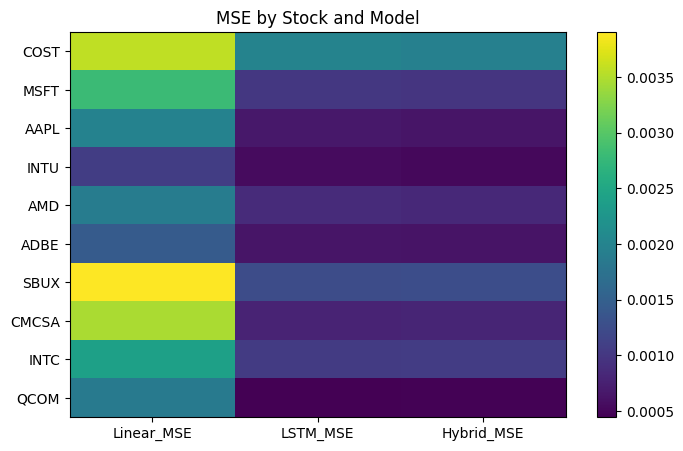

,Linear_MSE,LSTM_MSE,Hybrid_MSE
Ticker,,,
COST,0.003567,0.001989,0.001952
MSFT,0.002797,0.001004,0.000978
AAPL,0.001978,0.000671,0.000647
INTU,0.001077,0.000544,0.000520
AMD,0.001894,0.000869,0.000848
ADBE,0.001435,0.000643,0.000629
SBUX,0.003902,0.001254,0.001266
CMCSA,0.003464,0.000787,0.000802
INTC,0.002413,0.001044,0.001059


In [25]:
# CELL 24 — Heatmap MSE theo từng mã
heatmap_df = stock_mse_df.set_index("Ticker")[["Linear_MSE", "LSTM_MSE", "Hybrid_MSE"]]

plt.figure(figsize=(8, 5))
plt.imshow(heatmap_df.values, aspect="auto")
plt.xticks(range(heatmap_df.shape[1]), heatmap_df.columns)
plt.yticks(range(heatmap_df.shape[0]), heatmap_df.index)
plt.title("MSE by Stock and Model")
plt.colorbar()
plt.show()

heatmap_df

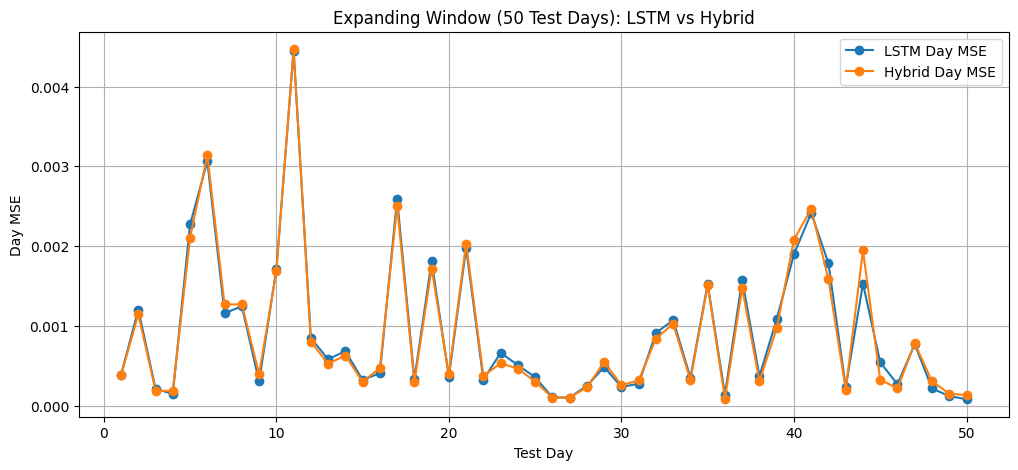

In [26]:
# CELL 25 — Plot Hybrid vs LSTM theo 50 ngày cuối
plt.figure(figsize=(12, 5))
plt.plot(compare_step_df["Step"], compare_step_df["LSTM_Day_MSE"], label="LSTM Day MSE", marker="o")
plt.plot(compare_step_df["Step"], compare_step_df["Hybrid_Day_MSE"], label="Hybrid Day MSE", marker="o")
plt.title("Expanding Window (50 Test Days): LSTM vs Hybrid")
plt.xlabel("Test Day")
plt.ylabel("Day MSE")
plt.legend()
plt.grid(True)
plt.show()